# 03 — Analyse Exploratoire des Données (EDA)

**Objectif :** Comprendre les patterns, corrélations et insights clés du dataset.  
**Entrée :** `data/processed/accidents_clean.parquet`

---

In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from utils import load_dataframe, GRAVITE_COLORS, PALETTE, cramers_v, CLEAN_DATA_FILE
from visualization import (
    plot_gravite_distribution, plot_temporal_heatmap, plot_hourly_risk,
    plot_causes_analysis, plot_speed_boxplot, plot_region_radar,
    plot_tendance_annuelle, plot_sankey_causes_gravite, plot_dashboard_overview
)

plt.rcParams['figure.dpi'] = 120
FIGURES = Path('../reports/figures')
FIGURES.mkdir(parents=True, exist_ok=True)

df = load_dataframe('../data/processed/accidents_clean.parquet')
print(f'Dataset chargé : {df.shape}')

2026-05-21 19:25:51 | INFO     | utils | DataFrame chargé ← ..\data\processed\accidents_clean.parquet (49,783 lignes)


Dataset chargé : (49783, 30)


## 1. Vue d'ensemble — Dashboard synthétique

2026-05-21 19:25:53 | INFO     | visualization | Figure sauvegardée : ..\reports\figures\03_dashboard_overview.png


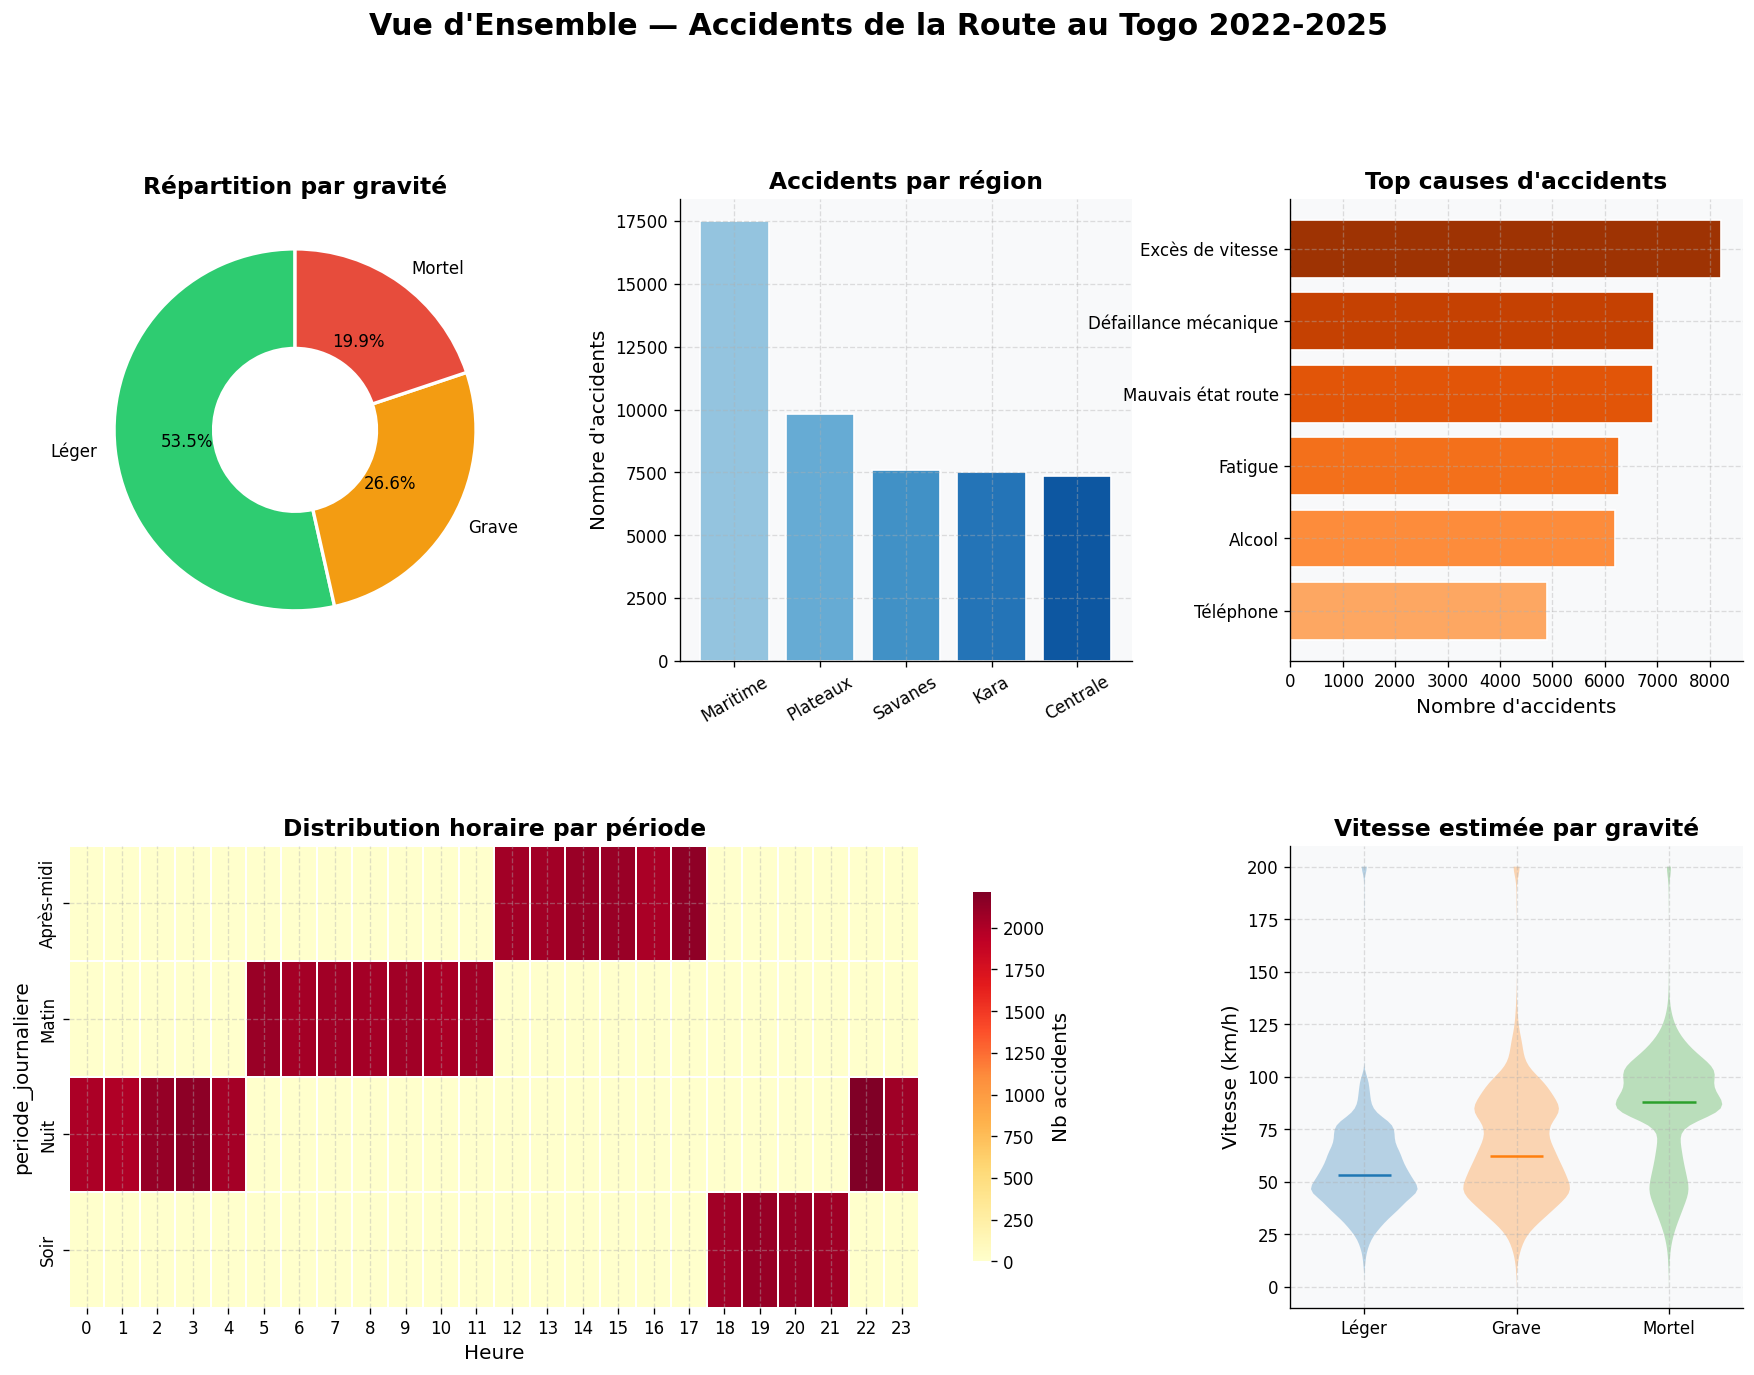

In [2]:
fig = plot_dashboard_overview(df, FIGURES / '03_dashboard_overview.png')
plt.show()

## 2. Analyse temporelle approfondie

2026-05-21 19:25:56 | INFO     | visualization | Figure sauvegardée : ..\reports\figures\03_heatmap_temporelle.png


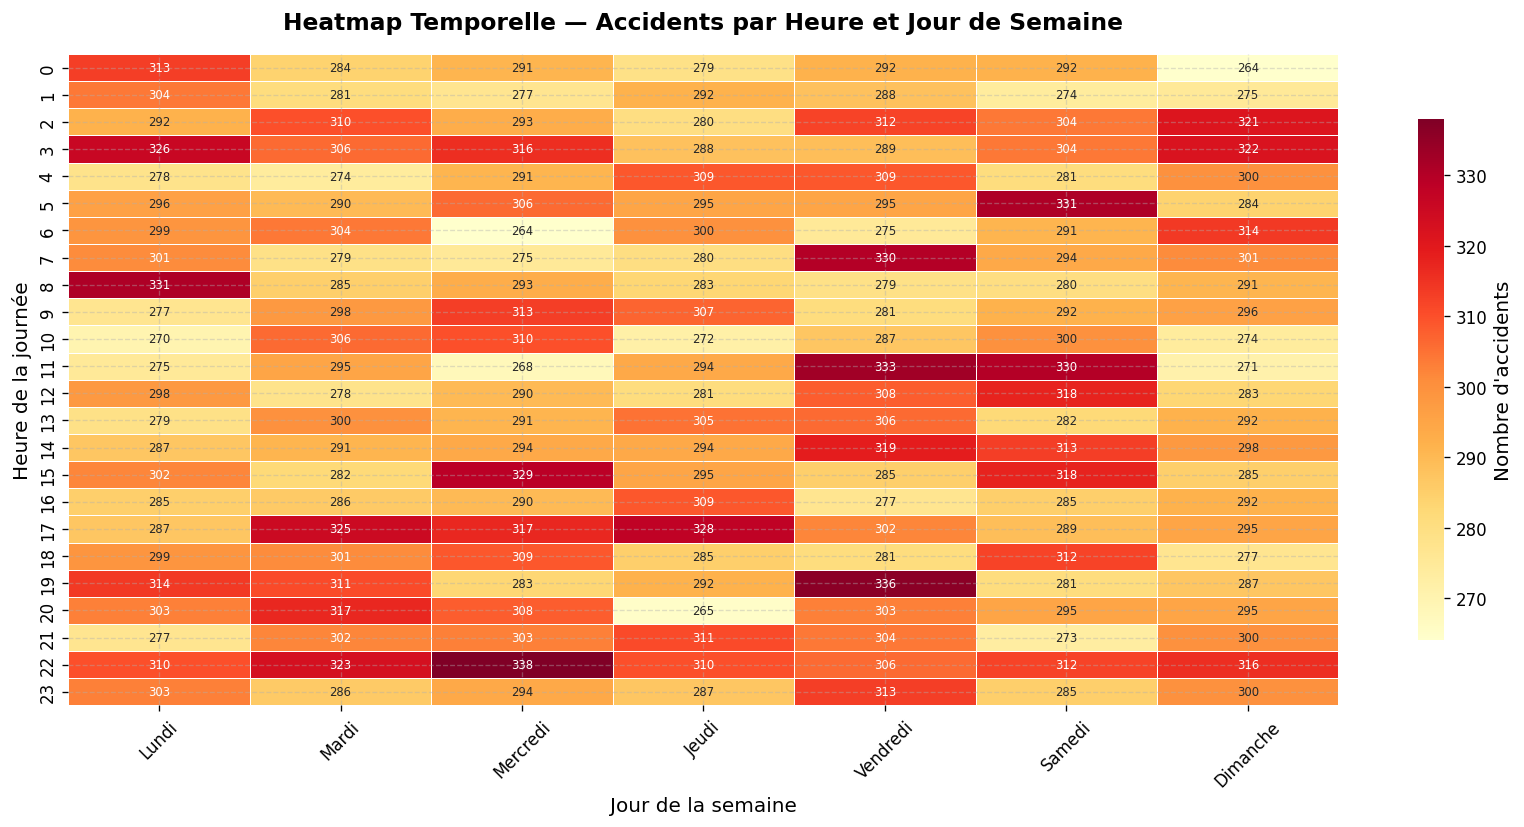

2026-05-21 19:25:58 | INFO     | visualization | Figure sauvegardée : ..\reports\figures\03_profil_horaire.png


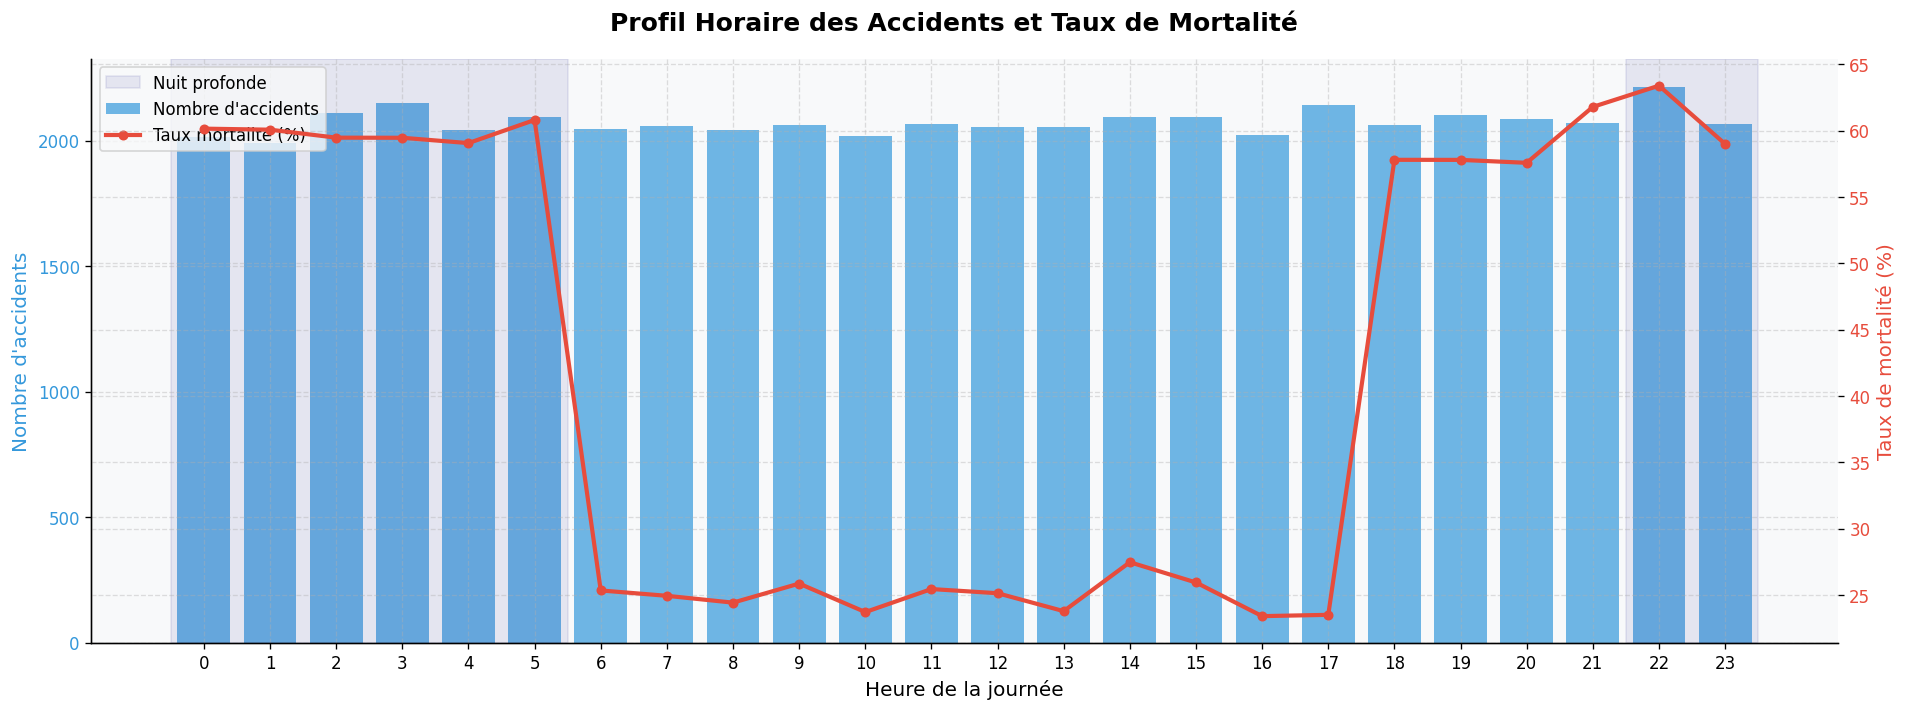

In [3]:
# Heatmap temporelle
fig_heatmap = plot_temporal_heatmap(df, FIGURES / '03_heatmap_temporelle.png')
plt.show()

# Profil horaire
fig_hourly = plot_hourly_risk(df, FIGURES / '03_profil_horaire.png')
plt.show()

In [4]:
# Évolution mensuelle interactive
fig_trend = plot_tendance_annuelle(df)
fig_trend.show()

Impact des jours fériés sur les accidents :
               nb_accidents  taux_mortalite  vitesse_moy  cout_moyen
accident_fete                                                       
Non                   49496           19.84    64.279999  2144461.10
Oui                     287           21.95    65.139999  2506118.91


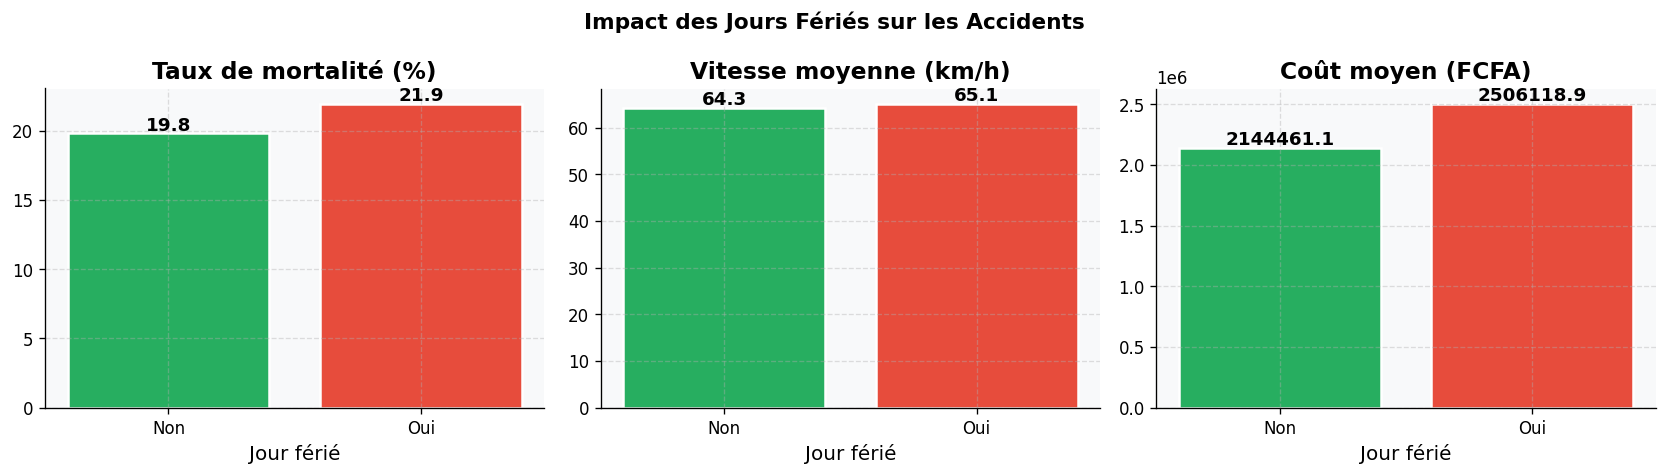

In [5]:
# Comparaison jours fériés vs ordinaires
fete_stats = df.groupby('accident_fete').agg(
    nb_accidents=('accident_id', 'count'),
    taux_mortalite=('gravite', lambda x: (x == 'Mortel').mean() * 100),
    vitesse_moy=('vitesse_estimee', 'mean'),
    cout_moyen=('cout_estime', 'mean')
).round(2)

print('Impact des jours fériés sur les accidents :')
print(fete_stats)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics = ['taux_mortalite', 'vitesse_moy', 'cout_moyen']
titles  = ['Taux de mortalité (%)', 'Vitesse moyenne (km/h)', 'Coût moyen (FCFA)']

for ax, metric, title in zip(axes, metrics, titles):
    values = fete_stats[metric]
    colors = ['#27ae60' if v == values.min() else '#e74c3c' for v in values]
    ax.bar(values.index, values.values, color=colors, edgecolor='white', linewidth=1.5)
    for i, (label, val) in enumerate(zip(values.index, values.values)):
        ax.text(i, val * 1.01, f'{val:.1f}', ha='center', fontsize=11, fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Jour férié')

plt.suptitle('Impact des Jours Fériés sur les Accidents', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / '03_jours_feries.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Analyse géographique

In [6]:
# Carte scatter des accidents
sample_map = df.sample(8000, random_state=42)

fig_map = px.scatter_mapbox(
    sample_map,
    lat='latitude', lon='longitude',
    color='gravite',
    color_discrete_map=GRAVITE_COLORS,
    size_max=6, opacity=0.5,
    zoom=6, center={'lat': 8.0, 'lon': 1.1},
    mapbox_style='carto-positron',
    hover_data=['ville', 'region', 'cause'],
    title='Localisation des accidents au Togo (échantillon 8000)'
)
fig_map.update_layout(height=550)
fig_map.show()

2026-05-21 19:26:13 | INFO     | visualization | Figure sauvegardée : ..\reports\figures\03_radar_regions.png


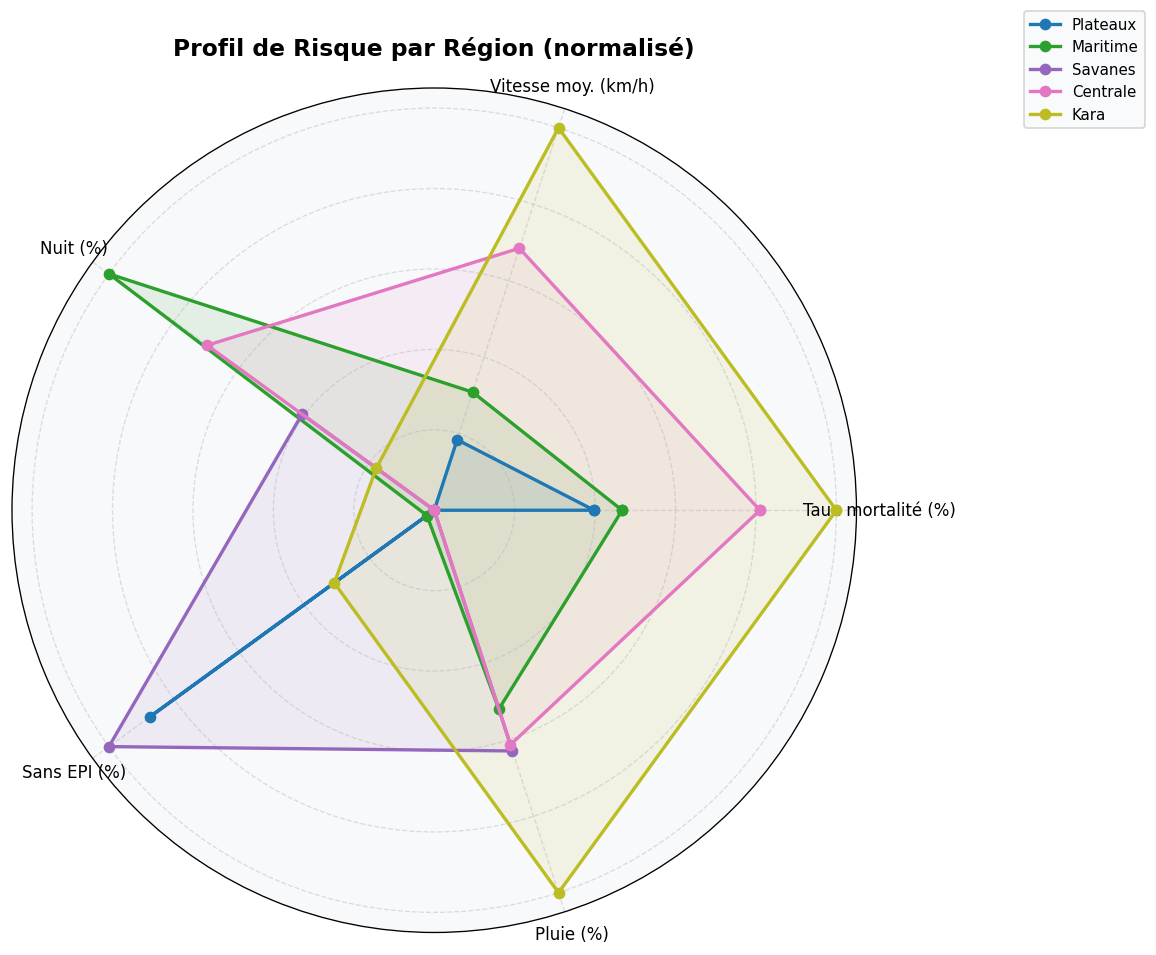

In [7]:
# Radar par région
fig_radar = plot_region_radar(df, FIGURES / '03_radar_regions.png')
plt.show()

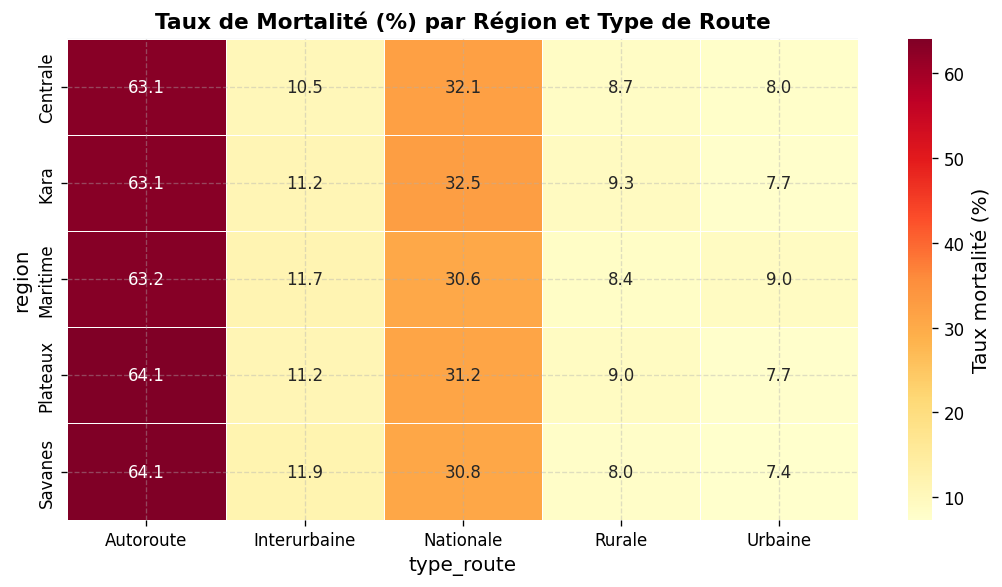

In [8]:
# Heatmap : région × type de route × taux mortalité
pivot_reg = (
    df.groupby(['region', 'type_route'])['gravite']
    .apply(lambda x: (x == 'Mortel').mean() * 100)
    .unstack('type_route')
    .round(2)
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(pivot_reg, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax,
            cbar_kws={'label': 'Taux mortalité (%)'}, linewidths=0.5)
ax.set_title('Taux de Mortalité (%) par Région et Type de Route', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / '03_heatmap_region_route.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Analyse des causes et comportements

2026-05-21 19:26:15 | INFO     | visualization | Figure sauvegardée : ..\reports\figures\03_causes.png


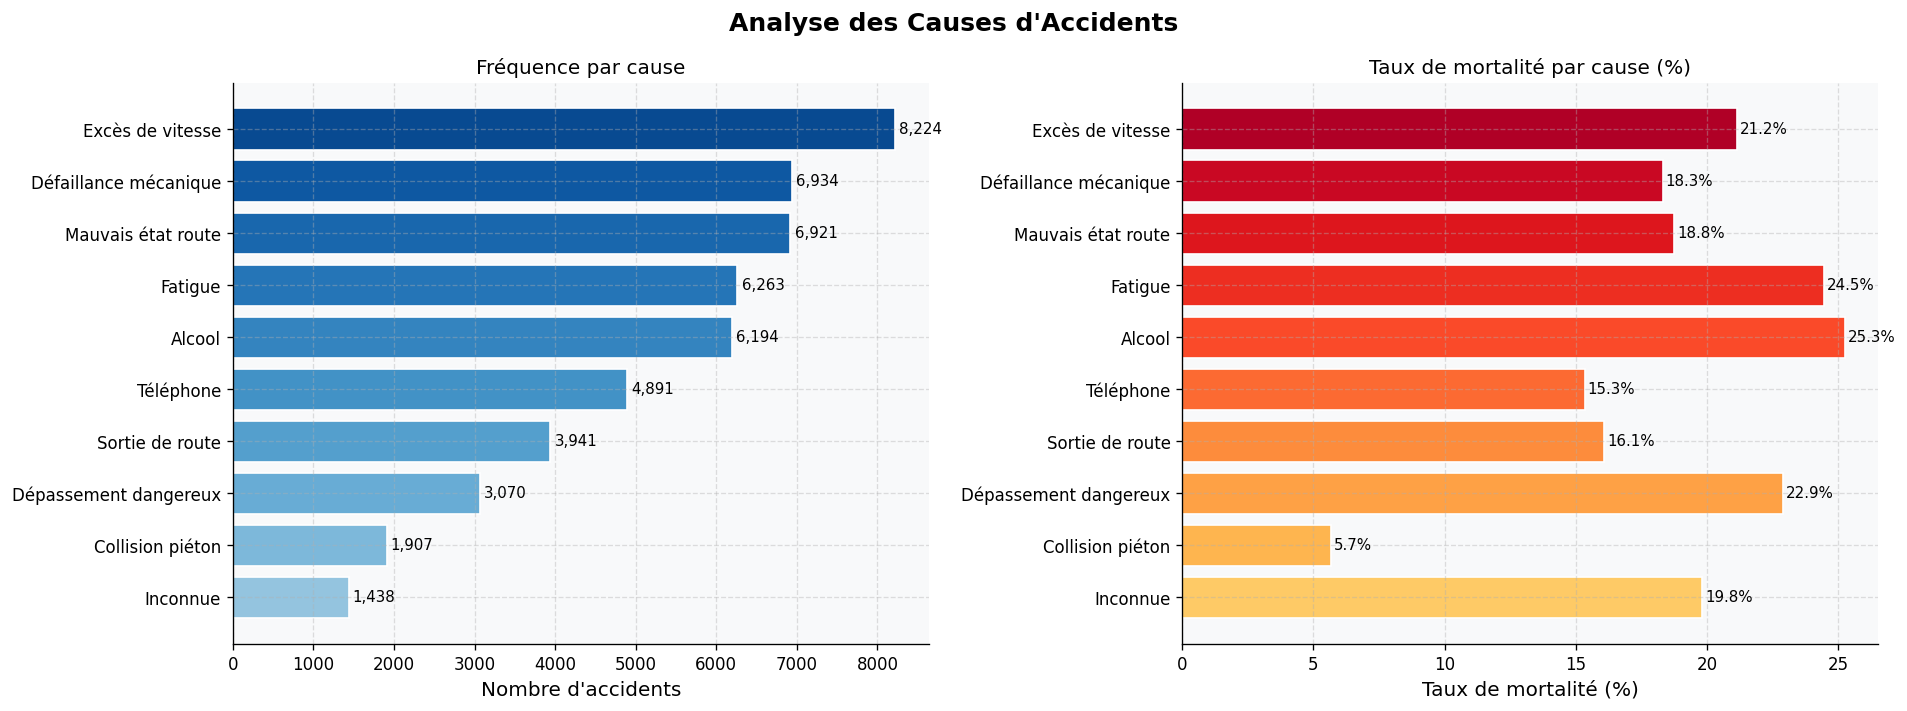

In [9]:
fig_causes = plot_causes_analysis(df, FIGURES / '03_causes.png')
plt.show()

# Sankey Cause → Gravité
fig_sankey = plot_sankey_causes_gravite(df)
fig_sankey.show()

In [10]:
# Port des EPI × Gravité
epi_grav = (
    df.groupby(['port_casque', 'port_ceinture', 'gravite'])
    .size().reset_index(name='count')
)

# ✅ Fix : Plotly ne supporte pas les Categorical non ordonnées
epi_grav['gravite'] = epi_grav['gravite'].astype(str)

fig = px.sunburst(
    epi_grav,
    path=['port_casque', 'port_ceinture', 'gravite'],
    values='count',
    color='gravite',
    color_discrete_map=GRAVITE_COLORS,
    title='Hiérarchie Port EPI → Gravité (Sunburst)'
)
fig.update_layout(height=450)
fig.show()

## 5. Analyse de la vitesse

2026-05-21 19:26:18 | INFO     | visualization | Figure sauvegardée : ..\reports\figures\03_vitesse_gravite.png


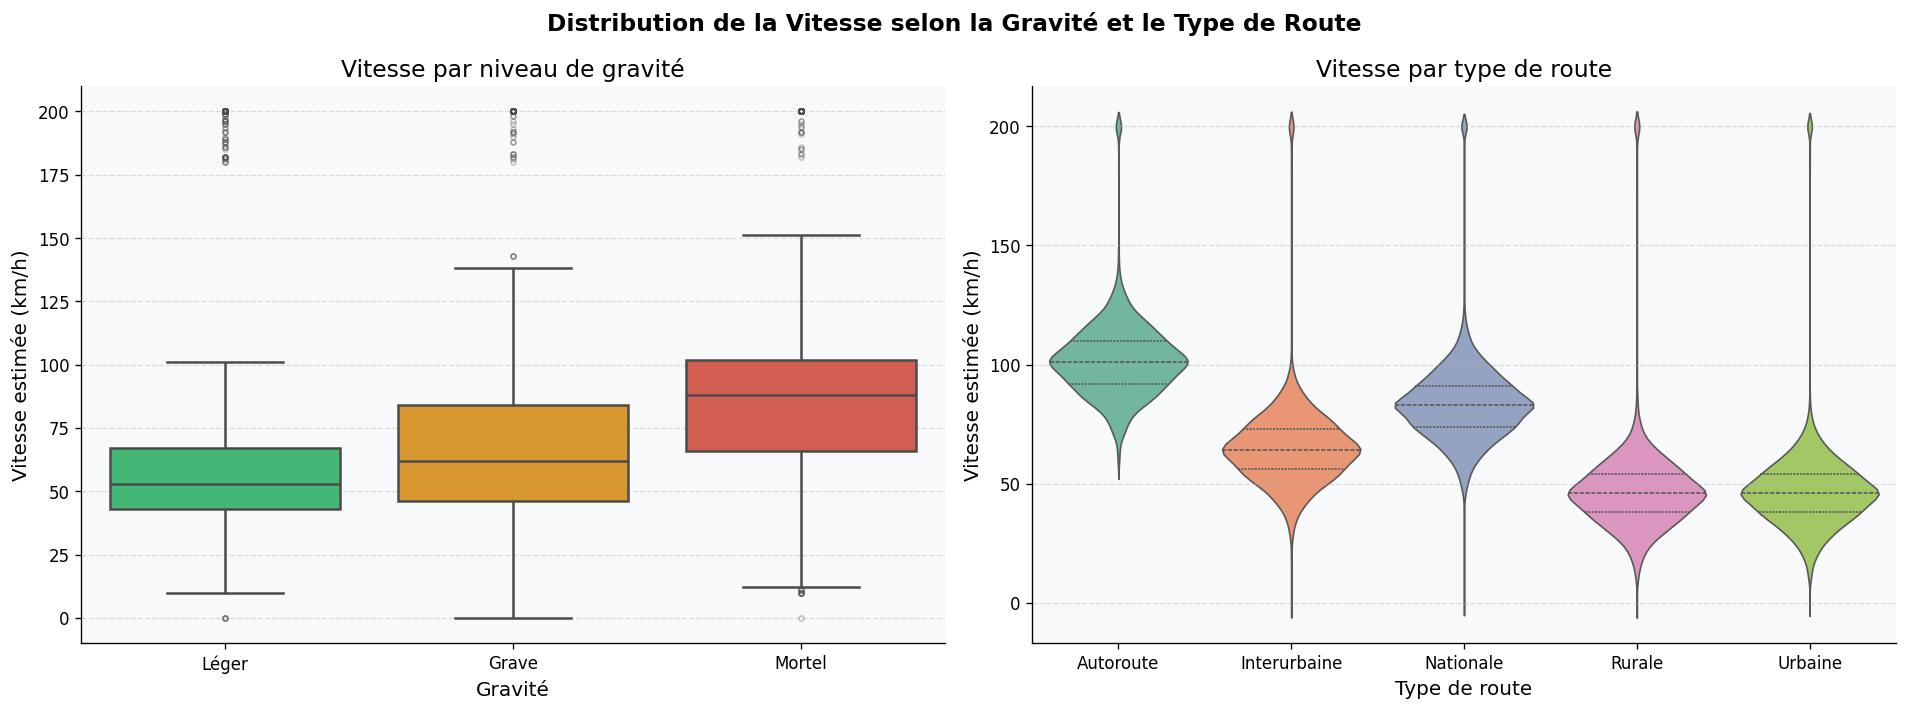

In [11]:
fig_speed = plot_speed_boxplot(df, FIGURES / '03_vitesse_gravite.png')
plt.show()

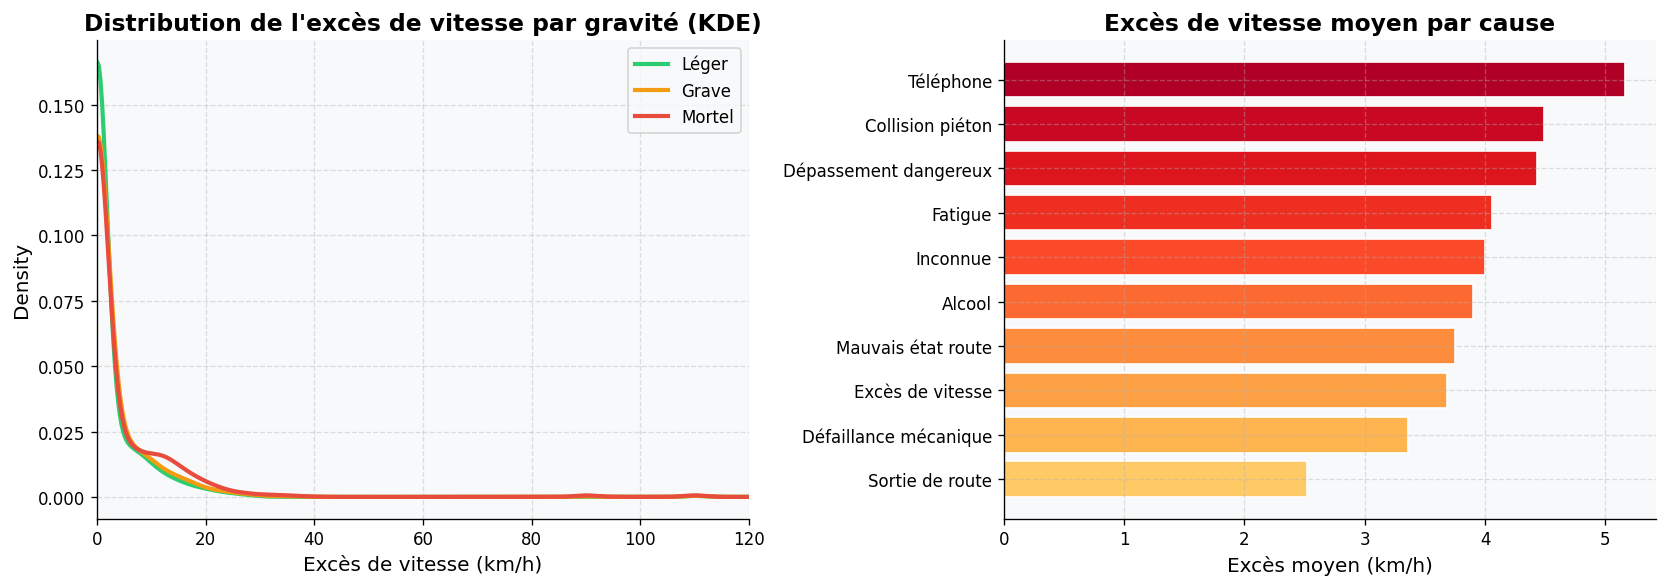

In [12]:
# Excès de vitesse
df['exces_vitesse'] = (df['vitesse_estimee'] - df['limitation_vitesse']).clip(lower=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KDE de l'excès de vitesse par gravité
for grav, color in GRAVITE_COLORS.items():
    sub = df[df['gravite'] == grav]['exces_vitesse']
    sub.plot.kde(ax=axes[0], label=grav, color=color, linewidth=2.5)
axes[0].set_title('Distribution de l\'excès de vitesse par gravité (KDE)', fontweight='bold')
axes[0].set_xlabel('Excès de vitesse (km/h)')
axes[0].legend()
axes[0].set_xlim(0, 120)

# Excès moyen par cause
exces_cause = df.groupby('cause')['exces_vitesse'].mean().sort_values(ascending=True)
colors = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(exces_cause)))
axes[1].barh(exces_cause.index, exces_cause.values, color=colors, edgecolor='white')
axes[1].set_title('Excès de vitesse moyen par cause', fontweight='bold')
axes[1].set_xlabel('Excès moyen (km/h)')

plt.tight_layout()
plt.savefig(FIGURES / '03_exces_vitesse.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Matrice de corrélation & associations

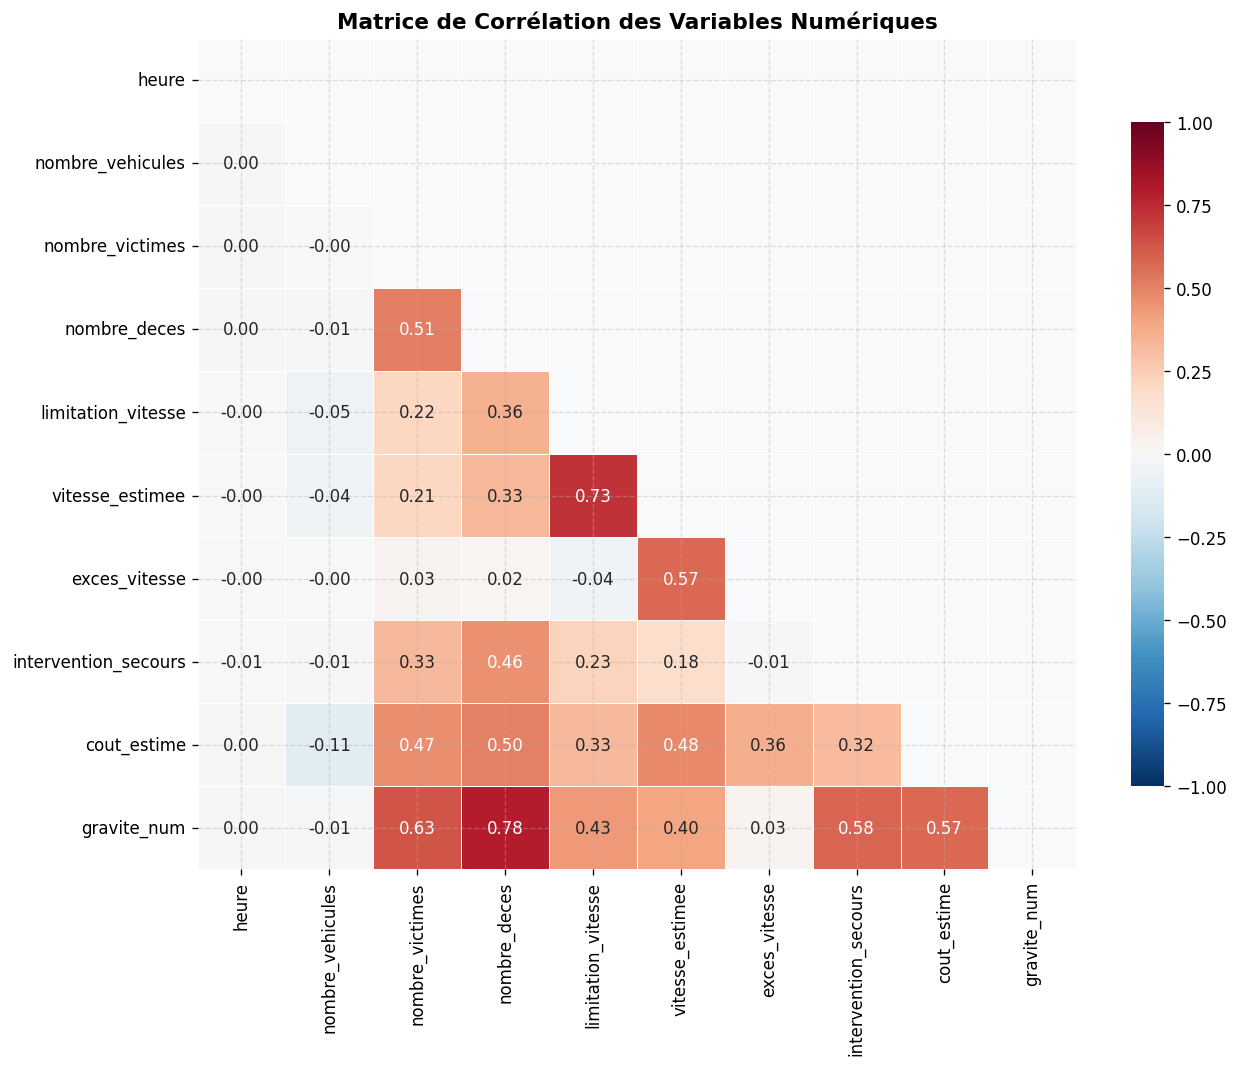

In [13]:
# Corrélation numérique
num_cols = ['heure', 'nombre_vehicules', 'nombre_victimes', 'nombre_deces',
            'limitation_vitesse', 'vitesse_estimee', 'exces_vitesse',
            'intervention_secours', 'cout_estime', 'gravite_num']

corr_matrix = df[num_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    ax=ax, linewidths=0.5, cbar_kws={'shrink': 0.8}
)
ax.set_title('Matrice de Corrélation des Variables Numériques', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / '03_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

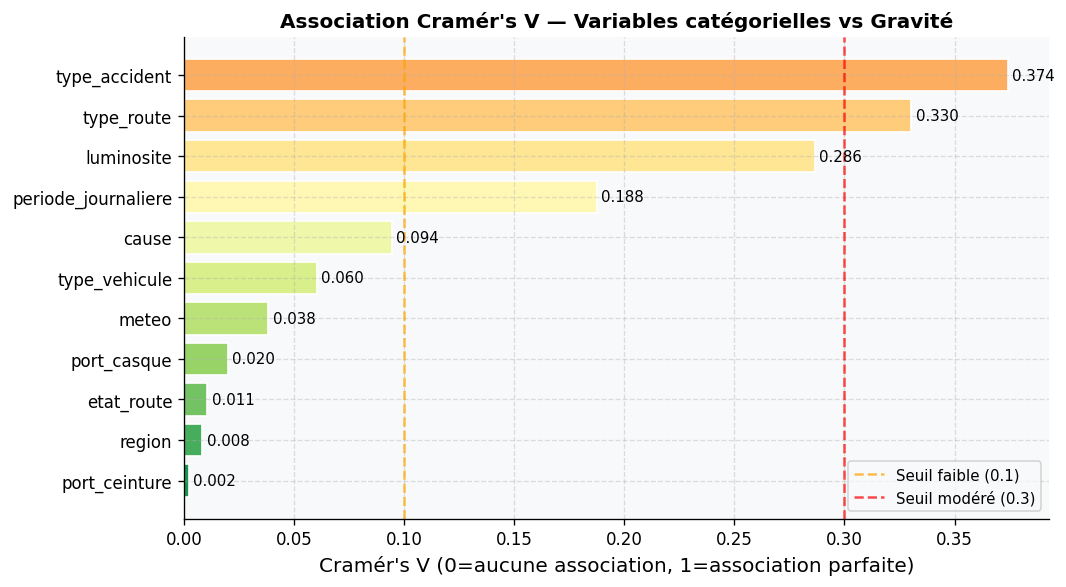

Top associations avec la gravité :
type_accident          0.3741
type_route             0.3303
luminosite             0.2864
periode_journaliere    0.1875
cause                  0.0944
type_vehicule          0.0603
meteo                  0.0383
port_casque            0.0198
etat_route             0.0106
region                 0.0083
port_ceinture          0.0022
Name: Cramér's V, dtype: float64


In [14]:
cat_cols = ['region', 'type_route', 'meteo', 'luminosite', 'type_vehicule',
            'cause', 'etat_route', 'port_casque', 'port_ceinture',
            'type_accident', 'periode_journaliere']

cramers_results = {}
for col in cat_cols:
    v = cramers_v(df[col].astype(str), df['gravite'].astype(str))
    cramers_results[col] = round(v, 4)

cramers_df = pd.Series(cramers_results, name="Cramér's V").sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(cramers_df))[::-1])
bars = ax.barh(cramers_df.index[::-1], cramers_df.values[::-1], color=colors, edgecolor='white')
for bar, val in zip(bars, cramers_df.values[::-1]):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
ax.set_title("Association Cramér's V — Variables catégorielles vs Gravité",
             fontsize=12, fontweight='bold')
ax.set_xlabel("Cramér's V (0=aucune association, 1=association parfaite)")
ax.axvline(0.1, color='orange', linestyle='--', alpha=0.7, label='Seuil faible (0.1)')
ax.axvline(0.3, color='red', linestyle='--', alpha=0.7, label='Seuil modéré (0.3)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES / '03_cramers_v.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top associations avec la gravité :")
print(cramers_df)

## 7. Insights clés — Synthèse

In [15]:
print('═' * 60)
print('INSIGHTS CLÉS — TOGO ROAD ACCIDENTS EDA')
print('═' * 60)

# 1. Taux de mortalité global
tx_mort = (df['gravite'] == 'Mortel').mean() * 100
print(f'\n1. MORTALITÉ')
print(f'   Taux de mortalité global : {tx_mort:.2f}%')
print(f'   Décès totaux : {df["nombre_deces"].sum():,}')

# 2. Heure la plus dangereuse
mort_heure = df[df['gravite']=='Mortel'].groupby('heure').size()
print(f'\n2. TEMPOREL')
print(f'   Heure la plus meurtrière : {mort_heure.idxmax()}h ({mort_heure.max()} accidents mortels)')

# 3. Cause la plus meurtrière
mort_cause = df[df['gravite']=='Mortel']['cause'].value_counts()
print(f'\n3. CAUSES')
print(f'   Cause n°1 : {mort_cause.index[0]} ({mort_cause.iloc[0]:,} accidents mortels)')
print(f'   Cause n°2 : {mort_cause.index[1]} ({mort_cause.iloc[1]:,} accidents mortels)')

# 4. Région la plus dangereuse
mort_region = (
    df.groupby('region')['gravite']
    .apply(lambda x: (x == 'Mortel').mean() * 100)
    .sort_values(ascending=False)
)
print(f'\n4. GÉOGRAPHIE')
print(f'   Région la plus meurtrière : {mort_region.index[0]} ({mort_region.iloc[0]:.1f}%)')

# 5. Impact EPI
sans_casque = df[df['port_casque']=='Non']['gravite'].value_counts(normalize=True)['Mortel']*100 if 'Mortel' in df[df['port_casque']=='Non']['gravite'].values else 0
avec_casque = df[df['port_casque']=='Oui']['gravite'].value_counts(normalize=True)['Mortel']*100 if 'Mortel' in df[df['port_casque']=='Oui']['gravite'].values else 0
print(f'\n5. ÉQUIPEMENTS')
print(f'   Taux mortalité sans casque : {sans_casque:.2f}%')
print(f'   Taux mortalité avec casque : {avec_casque:.2f}%')
print(f'   Risque relatif : ×{sans_casque/avec_casque:.1f}' if avec_casque > 0 else '')

# 6. Coût économique
cout_total = df['cout_estime'].sum() / 1e9
print(f'\n6. ÉCONOMIQUE')
print(f'   Coût total estimé : {cout_total:.2f} milliards FCFA')
print('═' * 60)

════════════════════════════════════════════════════════════
INSIGHTS CLÉS — TOGO ROAD ACCIDENTS EDA
════════════════════════════════════════════════════════════

1. MORTALITÉ
   Taux de mortalité global : 19.86%
   Décès totaux : 21,112

2. TEMPOREL
   Heure la plus meurtrière : 22h (673 accidents mortels)

3. CAUSES
   Cause n°1 : Excès de vitesse (1,740 accidents mortels)
   Cause n°2 : Alcool (1,564 accidents mortels)

4. GÉOGRAPHIE
   Région la plus meurtrière : Kara (20.4%)

5. ÉQUIPEMENTS
   Taux mortalité sans casque : 17.68%
   Taux mortalité avec casque : 20.13%
   Risque relatif : ×0.9

6. ÉCONOMIQUE
   Coût total estimé : 106.86 milliards FCFA
════════════════════════════════════════════════════════════


In [ ]:
print(' EDA terminée — figures sauvegardées dans reports/figures/')
print('Prochaine étape : notebook 04_sql_analysis.ipynb')

✓ EDA terminée — figures sauvegardées dans reports/figures/
→ Prochaine étape : notebook 04_sql_analysis.ipynb
